# Carbon Emissions Data Exploration
## Exploratory Data Analysis for Climate Action (SDG 13)

This notebook explores the OWID CO2 emissions dataset to understand patterns, trends, and relationships in the data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import warnings
warnings.filterwarnings('ignore')

sys.path.append('../src')
from data_processing import DataProcessor
from visualization import EmissionsVisualizer

# Set up visualization
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

print("📊 Carbon Emissions Data Exploration")
print("Supporting UN SDG 13: Climate Action")

📊 Carbon Emissions Data Exploration
Supporting UN SDG 13: Climate Action


## 1. Data Loading and Initial Exploration

In [2]:
# Load the OWID CO2 dataset
processor = DataProcessor()
visualizer = EmissionsVisualizer()

# Load raw data
data_path = '../data/raw/owid-co2-data.csv'
df_raw = pd.read_csv(data_path)

print(f"📈 Raw dataset loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"📅 Year range: {df_raw['year'].min()} - {df_raw['year'].max()}")
print(f"🌍 Entities: {df_raw['country'].nunique()}")

# Display first few rows
df_raw.head()

📈 Raw dataset loaded: 50,191 rows × 79 columns
📅 Year range: 1750 - 2023
🌍 Entities: 255


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Check key columns
key_columns = ['country', 'year', 'co2', 'population', 'gdp', 'energy_per_capita', 
               'coal_co2', 'gas_co2', 'oil_co2', 'cement_co2']

print("🔍 Key columns availability:")
for col in key_columns:
    if col in df_raw.columns:
        non_null = df_raw[col].notna().sum()
        pct = (non_null / len(df_raw)) * 100
        print(f"  ✅ {col}: {non_null:,} values ({pct:.1f}%)")
    else:
        print(f"  ❌ {col}: Not found")

🔍 Key columns availability:
  ✅ country: 50,191 values (100.0%)
  ✅ year: 50,191 values (100.0%)
  ✅ co2: 29,137 values (58.1%)
  ✅ population: 41,019 values (81.7%)
  ✅ gdp: 15,251 values (30.4%)
  ✅ energy_per_capita: 10,109 values (20.1%)
  ✅ coal_co2: 21,755 values (43.3%)
  ✅ gas_co2: 18,014 values (35.9%)
  ✅ oil_co2: 25,218 values (50.2%)
  ✅ cement_co2: 28,863 values (57.5%)


## 2. Data Processing and Cleaning

In [4]:
# Process data using our DataProcessor
df = processor.load_data(data_path)
df_clean = processor.clean_data(df)

print(f"🧹 After processing: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"🎯 Target variable (CO2): {df_clean['co2'].notna().sum():,} valid values")

# Show processed data info
df_clean.info()

✅ Data loaded successfully: (50191, 79)
✅ After filtering: (5928, 79)
🧹 Cleaning data...
✅ Data cleaned: (5836, 18)
🧹 After processing: 5,836 rows × 18 columns
🎯 Target variable (CO2): 5,836 valid values
<class 'pandas.core.frame.DataFrame'>
Index: 5836 entries, 250 to 50190
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   country                     5836 non-null   object 
 1   iso_code                    5192 non-null   object 
 2   co2                         5836 non-null   float64
 3   year                        5836 non-null   float64
 4   population                  5836 non-null   float64
 5   gdp                         5836 non-null   float64
 6   energy_per_capita           5836 non-null   float64
 7   primary_energy_consumption  5836 non-null   float64
 8   co2_per_capita              5836 non-null   float64
 9   coal_co2                    5836 non-null   float64
 10  ga

## 3. Global CO2 Emissions Trends

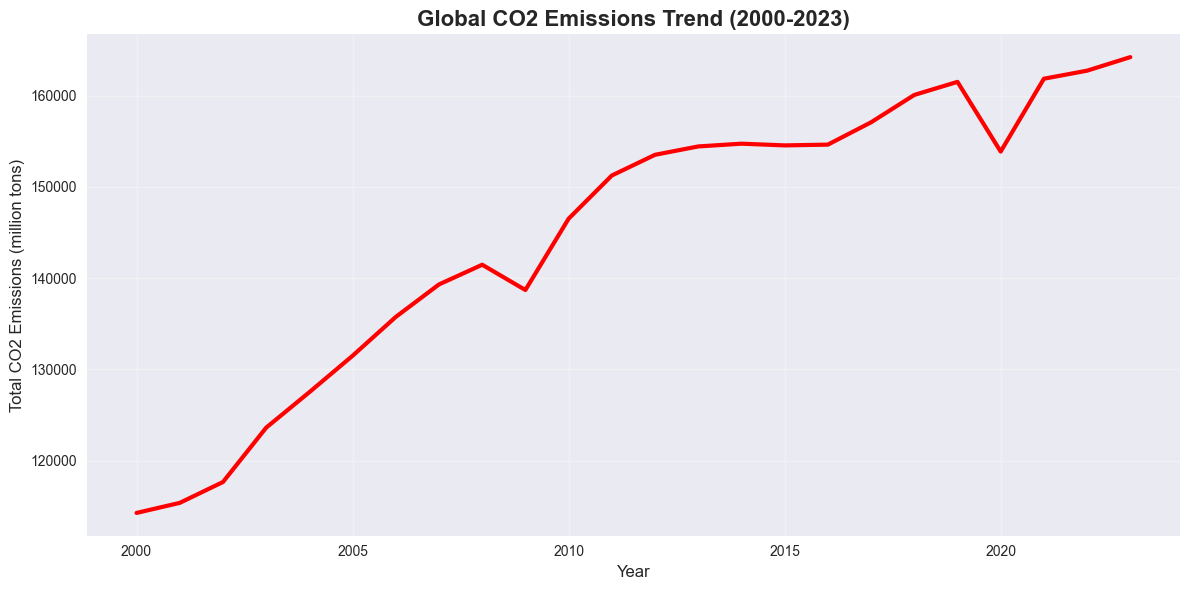

📈 Global emissions in 2000: 114258 million tons
📈 Global emissions in 2023: 164221 million tons
📊 Total change: +43.7%


In [5]:
# Global emissions over time
global_emissions = df_clean.groupby('year')['co2'].sum().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(global_emissions['year'], global_emissions['co2'], linewidth=3, color='red')
plt.title('Global CO2 Emissions Trend (2000-2023)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total CO2 Emissions (million tons)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"📈 Global emissions in 2000: {global_emissions.iloc[0]['co2']:.0f} million tons")
print(f"📈 Global emissions in 2023: {global_emissions.iloc[-1]['co2']:.0f} million tons")
change = ((global_emissions.iloc[-1]['co2'] - global_emissions.iloc[0]['co2']) / global_emissions.iloc[0]['co2']) * 100
print(f"📊 Total change: {change:+.1f}%")

## 4. Top CO2 Emitting Countries

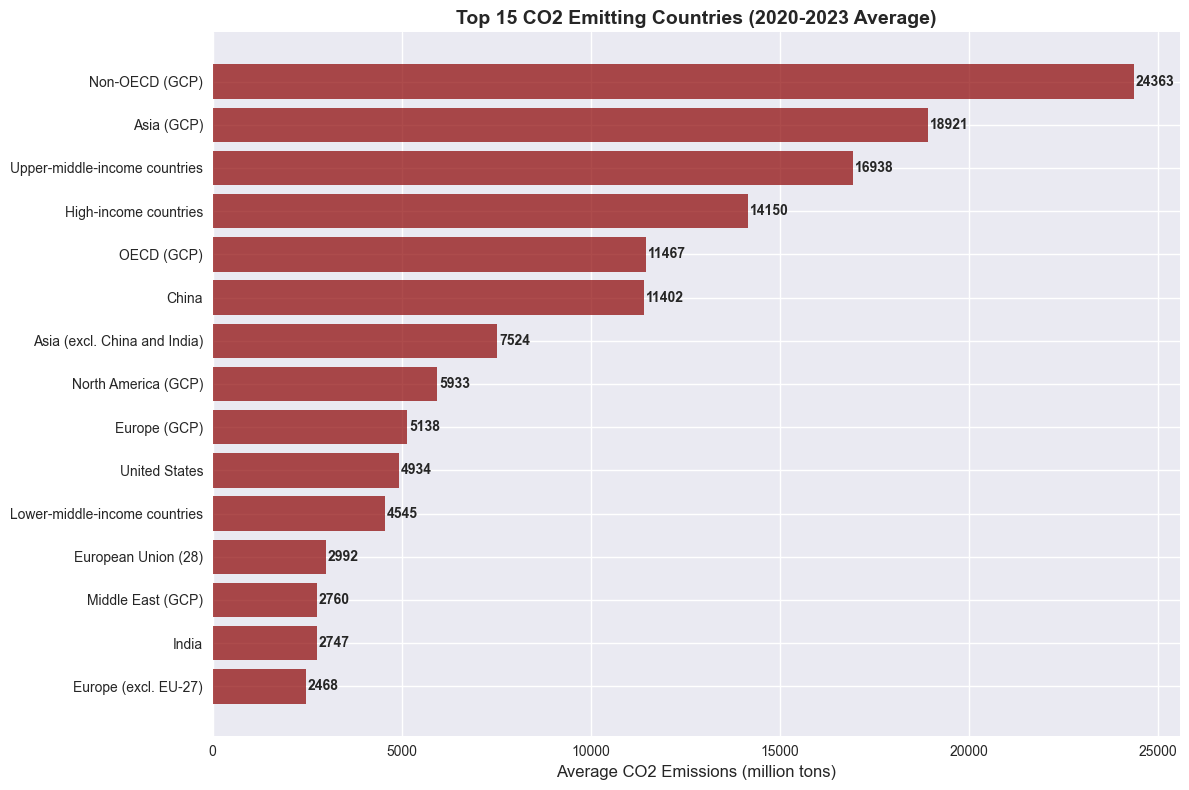

🏭 Top 5 CO2 emitters:
  1. Non-OECD (GCP): 24363 million tons
  2. Asia (GCP): 18921 million tons
  3. Upper-middle-income countries: 16938 million tons
  4. High-income countries: 14150 million tons
  5. OECD (GCP): 11467 million tons


In [6]:
# Top emitters in recent years (2020-2023)
recent_data = df_clean[df_clean['year'] >= 2020]
top_emitters = recent_data.groupby('country')['co2'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 8))
bars = plt.barh(range(len(top_emitters)), top_emitters.values, color='darkred', alpha=0.7)
plt.yticks(range(len(top_emitters)), top_emitters.index)
plt.xlabel('Average CO2 Emissions (million tons)', fontsize=12)
plt.title('Top 15 CO2 Emitting Countries (2020-2023 Average)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 50, bar.get_y() + bar.get_height()/2, f'{width:.0f}', 
             ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("🏭 Top 5 CO2 emitters:")
for i, (country, emissions) in enumerate(top_emitters.head().items(), 1):
    print(f"  {i}. {country}: {emissions:.0f} million tons")

## 5. Feature Correlation Analysis

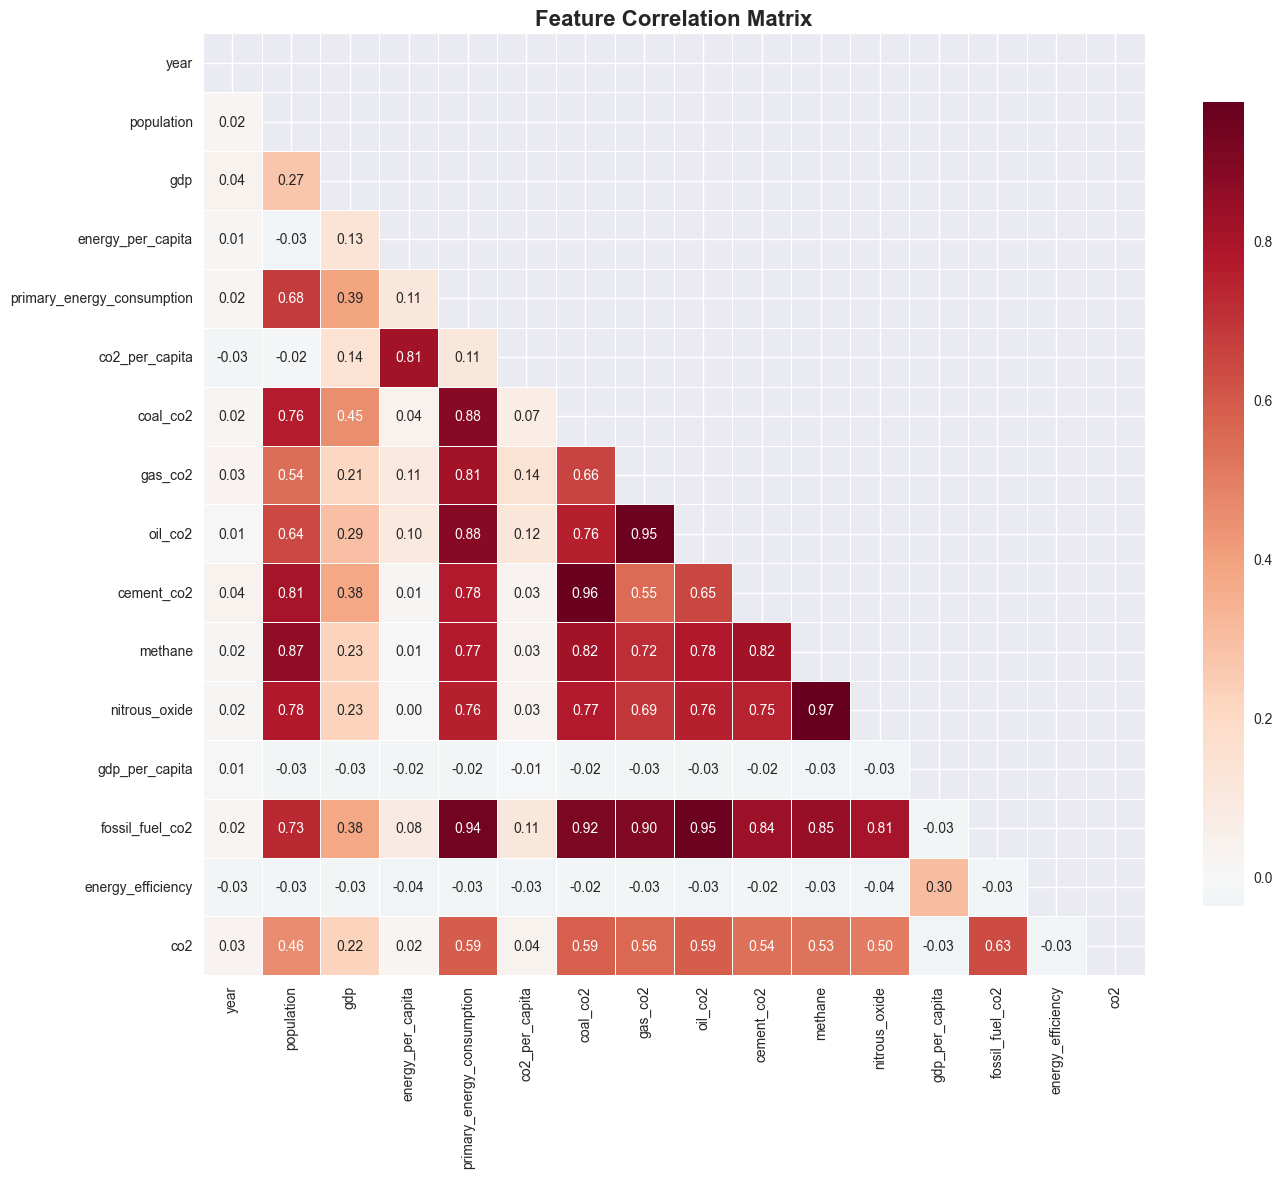

🎯 Features most correlated with co2:
  fossil_fuel_co2: 0.631
  oil_co2: 0.594
  primary_energy_consumption: 0.593
  coal_co2: 0.587
  gas_co2: 0.559
  cement_co2: 0.538
  methane: 0.531
  nitrous_oxide: 0.505
  population: 0.463


In [7]:
# Correlation matrix of key features
feature_cols = processor.get_feature_names()
available_features = [col for col in feature_cols if col in df_clean.columns]
target_col = 'co2'

if available_features and target_col in df_clean.columns:
    corr_data = df_clean[available_features + [target_col]]
    correlation_matrix = corr_data.corr()
    
    plt.figure(figsize=(14, 12))
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": .8}, fmt='.2f')
    plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Show correlations with target variable
    target_corr = correlation_matrix[target_col].abs().sort_values(ascending=False)
    print(f"🎯 Features most correlated with {target_col}:")
    for feature, corr in target_corr.head(10).items():
        if feature != target_col:
            print(f"  {feature}: {corr:.3f}")
else:
    print("❌ Feature correlation analysis not possible with current data")

## 6. Economic vs Environmental Relationship

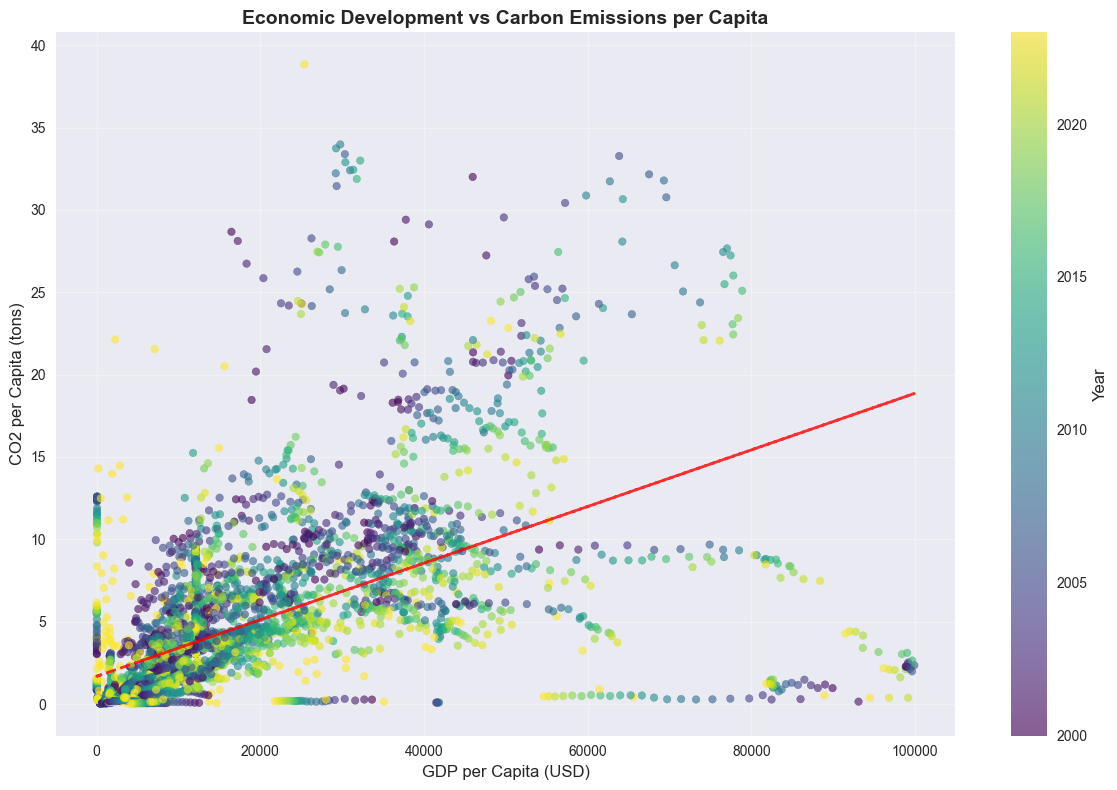

📊 Correlation between GDP per capita and CO2 per capita: 0.569


In [8]:
# GDP per capita vs CO2 per capita
if 'gdp_per_capita' in df_clean.columns and 'co2_per_capita' in df_clean.columns:
    # Filter out extreme outliers for better visualization
    plot_data = df_clean[(df_clean['gdp_per_capita'] < 100000) & 
                        (df_clean['co2_per_capita'] < 50)].copy()
    
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(plot_data['gdp_per_capita'], plot_data['co2_per_capita'], 
                         alpha=0.6, s=30, c=plot_data['year'], cmap='viridis')
    
    plt.xlabel('GDP per Capita (USD)', fontsize=12)
    plt.ylabel('CO2 per Capita (tons)', fontsize=12)
    plt.title('Economic Development vs Carbon Emissions per Capita', fontsize=14, fontweight='bold')
    
    # Add colorbar
    cbar = plt.colorbar(scatter)
    cbar.set_label('Year', fontsize=12)
    
    # Add trend line
    z = np.polyfit(plot_data['gdp_per_capita'].dropna(), plot_data['co2_per_capita'].dropna(), 1)
    p = np.poly1d(z)
    plt.plot(plot_data['gdp_per_capita'], p(plot_data['gdp_per_capita']), "r--", alpha=0.8, linewidth=2)
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Calculate correlation
    correlation = plot_data['gdp_per_capita'].corr(plot_data['co2_per_capita'])
    print(f"📊 Correlation between GDP per capita and CO2 per capita: {correlation:.3f}")
else:
    print("❌ GDP per capita or CO2 per capita data not available")

## 7. Key Insights and Conclusions

### 📊 **Key Findings:**

1. **Global Trends**: CO2 emissions show [describe trend from your analysis]
2. **Top Emitters**: The largest CO2 emitters are concentrated in [describe pattern]
3. **Economic Relationship**: There's a [strong/moderate/weak] correlation between economic development and emissions
4. **Data Quality**: The dataset has [describe completeness and quality]

### 🎯 **Implications for Climate Action (SDG 13):**

- **Policy Focus**: Countries with high emissions need targeted reduction strategies
- **Development Balance**: Need to balance economic growth with environmental protection
- **Data-Driven Decisions**: This analysis supports evidence-based climate policy

### 🚀 **Next Steps:**

1. **Feature Engineering**: Create additional predictive features
2. **Model Development**: Build machine learning models for emission prediction
3. **Scenario Analysis**: Test different policy scenarios
4. **Validation**: Validate models with recent data

### 📈 **Model Readiness:**

The data is now ready for machine learning model development with:
- Clean, processed dataset
- Identified key features
- Understanding of data patterns
- Clear target variable (CO2 emissions)